### DATA 201 --- Week 5 Assignment
### Robert Gravatt --- March 26, 2026
#### Resampling Methods with the Iris Dataset

In this assignment, we will explore bootstrap resampling, jackknife resampling, and permutation tests using the Iris dataset.

The Iris dataset contains measurements of iris flowers from three species:

Setosa,
Versicolor,
Virginica

Each flower has four measurements:

sepal length,
sepal width,
petal length,
petal width

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the Dataset
iris = sns.load_dataset("iris")
display(iris.head())

# 1. Print the Number of observations in the dataset.
print(f"Total observations: {len(iris)}")

# 2. Print the Column names.
print(f"Column names: {iris.columns.tolist()}")

# 3. Count how many Observations exist for each species.
print("\nObservations per species:")
print(iris['species'].value_counts())

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Total observations: 150
Column names: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

Observations per species:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


Mean: 5.8433
Median: 5.8000
Std Dev: 0.8281


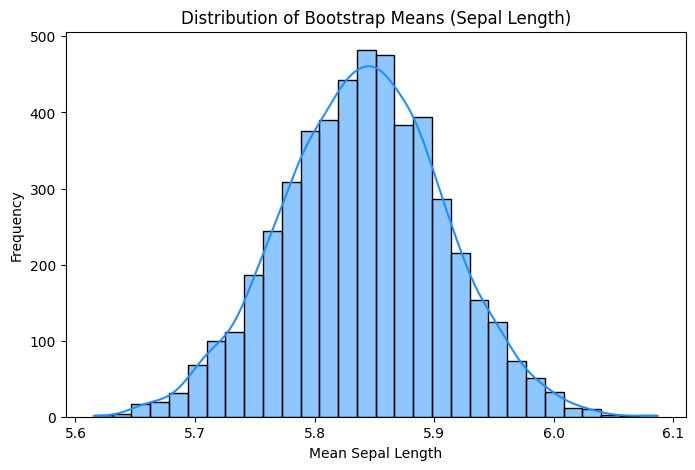


Bootstrap Mean: 5.8407
95% CI: [5.7067, 5.9714]


In [7]:
# Task 1 - Basic Statistics
sepal_length = iris['sepal_length']
print(f"Mean: {sepal_length.mean():.4f}")
print(f"Median: {sepal_length.median():.4f}")
print(f"Std Dev: {sepal_length.std():.4f}")

# Task 2 - Bootstrap the Mean - perform 5000 resamples
np.random.seed(666) # Ensure reproducible results
n_iterations = 5000
n_size = len(sepal_length) # 150 observations

bootstrap_means = []
for _ in range(n_iterations):
    # Sample with replacement
    sample = np.random.choice(sepal_length, size=n_size, replace=True) # size =150
    bootstrap_means.append(np.mean(sample))

# Plotting the Bootstrap Distribution
plt.figure(figsize=(8, 5))
sns.histplot(bootstrap_means, bins=30, kde=True, color='dodgerblue')
plt.title('Distribution of Bootstrap Means (Sepal Length)')
plt.xlabel('Mean Sepal Length')
plt.ylabel('Frequency')
plt.show()

# Task 3 - Confidence Interval
lower_bound = np.percentile(bootstrap_means, 2.5)
upper_bound = np.percentile(bootstrap_means, 97.5)
bootstrap_mean = np.mean(bootstrap_means)

print(f"\nBootstrap Mean: {bootstrap_mean:.4f}")
print(f"95% CI: [{lower_bound:.4f}, {upper_bound:.4f}]")

####Why is it mathematically necessary to sample with replacement?
If we sampled without replacement from a dataset of size $n$, taking a sample of size $n$, we would simply recreate the exact original dataset every single time. The variance of our statistic across iterations would be zero. Sampling with replacement mimics the process of drawing randomly from the original underlying population, allowing us to accurately estimate the variance and the sampling distribution.

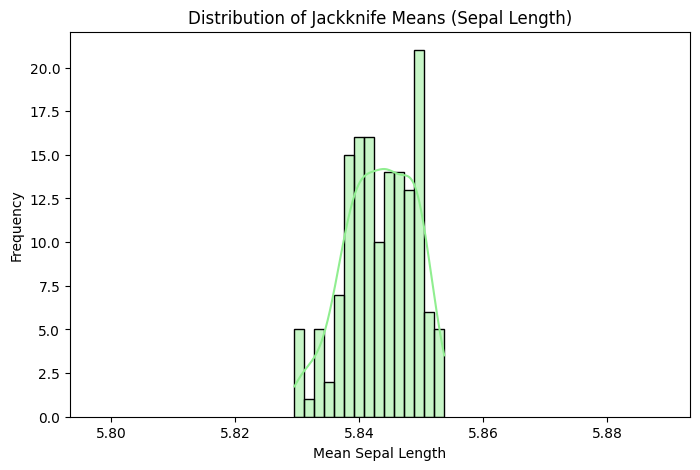

In [3]:
# Task 4 - Jackknife the Mean
jackknife_means = []

for i in range(n_size):
    # Remove one observation at a time using np.delete
    sample = np.delete(sepal_length.values, i)
    jackknife_means.append(np.mean(sample))

# Plotting the Jackknife Distribution
plt.figure(figsize=(8, 5))
sns.histplot(jackknife_means, bins=15, kde=True, color='lightgreen')
plt.title('Distribution of Jackknife Means (Sepal Length)')
plt.xlabel('Mean Sepal Length')
plt.ylabel('Frequency')

# Zooming in on the x-axis to see the variation clearly
mean_val = sepal_length.mean()
plt.xlim(mean_val - 0.05, mean_val + 0.05)
plt.show()

#### Exactly how many jackknife samples are created?
 Exactly $n$ samples. Since our dataset contains 150 observations, the jackknife method produces exactly 150 distinct samples.

Observed Difference (Versicolor - Virginica): -0.6520


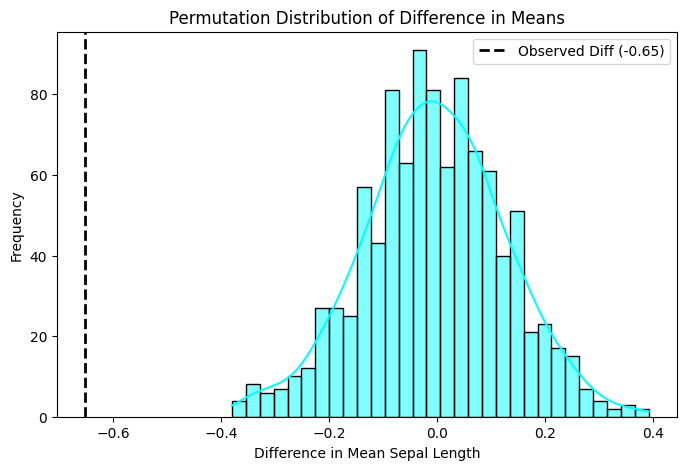


p-value: 0.0000


In [6]:
# Filter for Versicolor and Virginica
subset = iris[iris['species'].isin(['versicolor', 'virginica'])].copy()

versicolor_len = subset[subset['species'] == 'versicolor']['sepal_length'].values
virginica_len = subset[subset['species'] == 'virginica']['sepal_length'].values

# Task 5 - Observed Statistic
observed_diff = np.mean(versicolor_len) - np.mean(virginica_len)
print(f"Observed Difference (Versicolor - Virginica): {observed_diff:.4f}")

# Task 6 - Permutation Simulation
n_permutations = 1000
perm_diffs = []
all_lengths = subset['sepal_length'].values
n_versicolor = len(versicolor_len)

for _ in range(n_permutations):
    # Shuffle the combined lengths array in place
    np.random.shuffle(all_lengths)

    # Split back into two groups of original sizes
    fake_versicolor = all_lengths[:n_versicolor]
    fake_virginica = all_lengths[n_versicolor:]

    # Compute and store the difference
    diff = np.mean(fake_versicolor) - np.mean(fake_virginica)
    perm_diffs.append(diff)

# Plotting the Permutation Distribution
plt.figure(figsize=(8, 5))
sns.histplot(perm_diffs, bins=30, kde=True, color='cyan')
plt.axvline(observed_diff, color='black', linestyle='dashed', linewidth=2, label=f'Observed Diff ({observed_diff:.2f})')
plt.title('Permutation Distribution of Difference in Means')
plt.xlabel('Difference in Mean Sepal Length')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Task 7 - p-value (Using absolute values for a standard two-tailed test)
# How many simulated absolute differences are >= the absolute observed difference?
extreme_count = np.sum(np.abs(perm_diffs) >= np.abs(observed_diff))
p_value = extreme_count / n_permutations

print(f"\np-value: {p_value:.4f}")

#### 1. What is the null hypothesis ($H_0$) in this specific test?
There is no difference in the true mean sepal length between the Versicolor and Virginica species. Any observed difference in our sample is purely due to random chance.
#### 2. What does the permutation distribution represent in terms of random chance?
It represents the distribution of the test statistic (the difference in means) that we would expect to observe purely by random chance if the null hypothesis were true—that is, if the species labels had absolutely no relationship to the sepal lengths.
#### 3. Based on your p-value, do you reject or fail to reject the null hypothesis?
Because the calculated p-value ($0.0000$) is less than $\alpha = 0.05$, we reject the null hypothesis. There is a statistically significant difference in mean sepal length between the two species.